<div dir=rtl>

## מימוש GD


<div dir=rtl>


בשיעור הקודם דיברנו על אלגוריתם אופטימיזציה פשוט, gradient decent, אלגוריתם המחפש מינימום לפונקצית ה cost ע"י פעולה חמדנית - בכל נקודת זמן, לעשות צעד בכיוון שבו המחיר קטן הכי הרבה.

כעת נממש אלגוריתם כזה, בדיוק עבור הדוגמה הפשוטה בה דנו: קירוב של אוסף נקודות ע"י פרבולה מהמשפחה:

$$
f(x) = ax^2 + bx - 2
$$

את המספר $-2$בחרנו שרירותית. זה היה יכול להיות עוד פרמטר, אבל אנחנו מגבילים עצמינו לשני פרמטרים, בשביל שנוכל אחר כך לצייר את פונקציית המחיר.

<div dir=rtl>

### קצת על חישובים נומריים וחישובים סימבוליים


<div dir=rtl>

בתכנות אפשר לבצע שני סוגים של חישובים מתמטיים, נומריים וסימבולים. חישובים נומרים הם חישובים עם ערכים מספריים, בדרך כלל מיוצגים עם נקודה צפה.
הספרייה numpy של פייתון, מתמחה בחישובים כאלה, הרבה פעם במסגרת עבודה עם טנזורים - מטריצות רב ממדיות.

דרך אחרת לבצע חישובים מתמטיים היא הדרך הסימבולית, דרך דומה לחישבוים שאנחנו עושים כבני אדם, על ניר. לדוגמה, אפשר ליצג את המספר $\frac{1}{3}$ בצורה סימבולית כשבר פשוט, או בצורה נומרית ע"י הקירוב $0.333333$.
אפשר ליצג את $\sqrt{8}$ בצורה סמבולית כ $2\sqrt{2}$ או בצורה נומרית ע"י הקירוב: $2.828427125$.

בהינתן הפונקציה $f(x)=x^2$
אפשר למצוא קירוב לנגזרת שלה בנקודה $5$ ע"י החישוב:
$$
\frac{(5+0.000001)^2 - 5^2}{0.000001}=10.000001
$$
או לעשות מניפולציה על הסמלים, ולקבל ש:
$$
f'(x) = 2x
$$

$$
f'(5) = 2 \cdot 5 = 10
$$

כפי שאפשר לראות, יש יתרונות (אילו?) גם לחישוב סימבולי וגם לחישוב נומרי. בפייתון, הספריה שמתמחה בחישוב סימבולי, נקראת
sympy.

אגב, במספר מחשבונים מודרניים, ניתן לקבוע עם מעוניינים בחישובים נומריים או סימבוליים.

כעת נייבא את הספריה וניתן לה את הקיצור המקובל.

In [1]:
import sympy as sp

<div dir=rtl>

נדגים שימוש פשוט בספריה הסימבולית

In [2]:
# x, a and b are symbols that represents variables
x, a, b = sp.symbols('x a b')

# we define f to be equal to an expression containing a, b and x
f = a * x**2 + b * x - 2

print('The expression: ', f)
print('\nThe expression tree: ', sp.srepr(f))
print('\nThe expression in a more stylish mathematical way:')
display(f)

The expression:  a*x**2 + b*x - 2

The expression tree:  Add(Mul(Symbol('a'), Pow(Symbol('x'), Integer(2))), Mul(Symbol('b'), Symbol('x')), Integer(-2))

The expression in a more stylish mathematical way:


a*x**2 + b*x - 2

<div dir=rtl>

בשביל להציב ערכים במשתנים, נשתמש בפונקציה subs, לדוגמה:

In [3]:
g = f.subs([(a, 5), (b,3)])
display(g, f)

5*x**2 + 3*x - 2

a*x**2 + b*x - 2

<div dir=rtl>

מכיוון ש $g$ בדוגמה האחרונה היא כבר ביטוי התלוי רק ב $x$, אפשר להתייחס אליה כפונקציה במשתנה אחד, ולהציג את הגרף שלה:

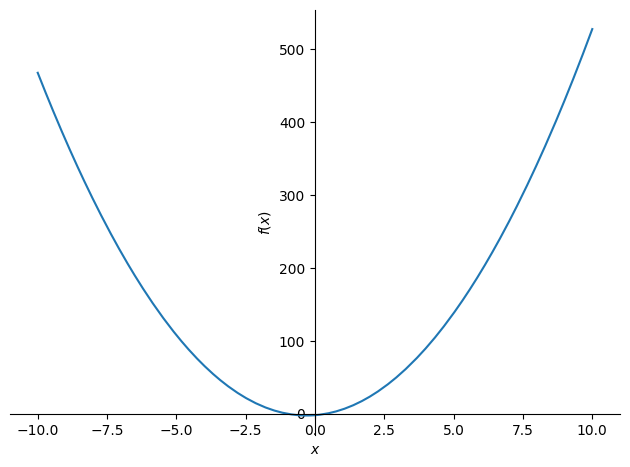

In [4]:
sp.plot(g)

<div dir=rtl>

ניתן גם להציג פונקציות בשני משתנים. לדוגמה:

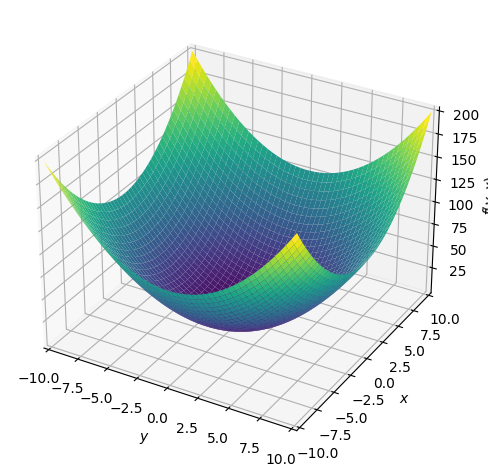

In [5]:
y = sp.Symbol('y')
sp.plotting.plot3d(x**2 + y**2)

<div dir=rtl>

כפי שראיתם, הגדרנו את $f$ להיות הביטוי שמיצג את המשפחה הפרמטרית שמתוכם אנחנו מחפשים את הקירוב, לאוסף הדוגמאות:

In [6]:
f

a*x**2 + b*x - 2

<div dir=rtl>

הנה שני מועמדים לדוגמה. פונקציות מהמשפחה שיכולות אולי להיות קירוב טוב:

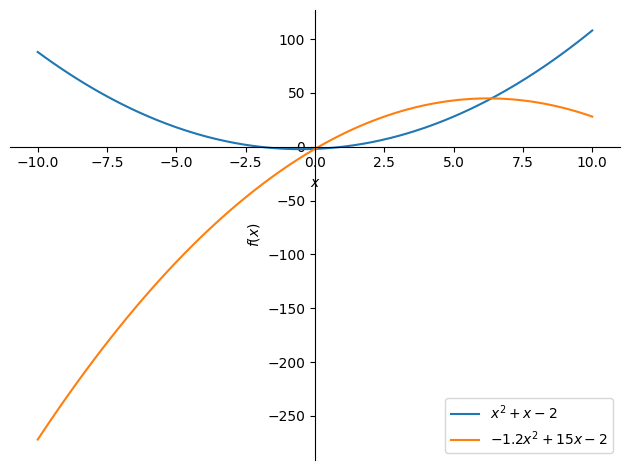

In [7]:
g1 = f.subs([(b, 1), (a, 1)])
g2 = f.subs([(b, 15), (a, -1.2)])
_ = sp.plot(g1, g2, legend=True)

<div dir=rtl>

בינתיים אין לנו אפילו אוסף דוגמאות קונקרטיות, אליו אפשר להתייחס.

בואו ניצור כזה. בשביל שנדע מראש מה התשובה הנכונה, נייצר אותו מפרבולה מסויימת, עם קצת רעש:

In [8]:
A = 4     # ground truth a
B = .6    # ground truth b

gt_f = f.subs([(a, A), (b, B)])
print(f'Ground truth:')
display(sp.Eq(sp.Function('f')(x), gt_f))

Ground truth:


Eq(f(x), 4*x**2 + 0.6*x - 2)

<div dir=rtl>

כמו כמעט בכול קוד מתמטי ב python, גם כאן אנו נזקקים ל numpy בגלל היכולות שלו:

In [9]:
import numpy as np

<div dir=rtl>

נכתוב פונקציה שיוצרת אוסף דוגמאות. ה x - יהיו במרווחים שווים וה y-ים, לקוחים מתוך הפונקציה שנחפש, וקצת רעש נורמלי.

In [10]:
def create_samples():
  global xs, ys
  N = 7
  xs = np.linspace(-10, 10, N)
  ns = np.random.randn(N) * 50
  ys = sp.lambdify(x, gt_f)(xs) + ns

In [11]:
import matplotlib.pyplot as plt

In [12]:
def show_function_and_samples(f):
  xt = np.linspace(-10, 10, 200)
  yt = sp.lambdify(x, f)(xt)

  plt.grid()
  plt.plot(xs, ys, 'rx')
  plt.plot(xt, yt)
  plt.title(f'f(x) = {f}\nSamples: {gt_f} + noise.')
  plt.show()

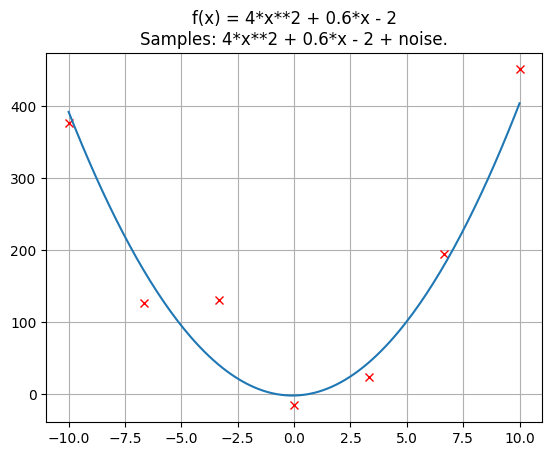

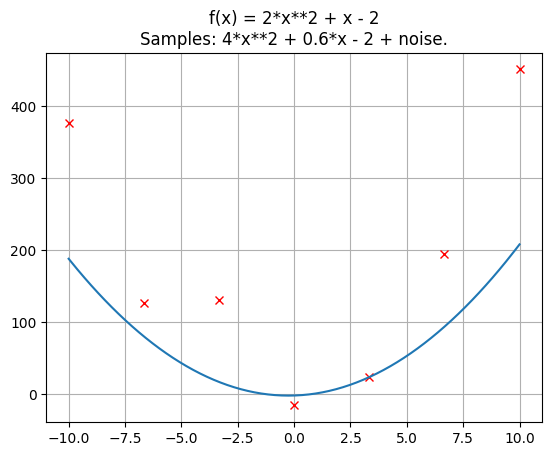

In [13]:
create_samples()

show_function_and_samples(gt_f)
f1 = f.subs([(a, 2), (b, 1)])
show_function_and_samples(f1)

$$
cost(a,b) = \frac{1}{N} \sum_{i=1}^{N}{(f_{a,b}(x_i)-y_i)^2}
$$

In [15]:
def compute_cost_function():
  cost = 0
  N = len(xs)
  for xi, yi in zip(xs, ys):
    fx = f.subs([(x, xi)])
    cost += (fx - yi) ** 2
  cost /= N
  return cost


cost = compute_cost_function()
print('cost(a,b) = ')
display(cost)

cost(a,b) = 


2514.34223154256*(0.0837522099667733*a - 0.025125662990032*b - 1)**2 + 29309.7491291822*(0.220772476526347*a + 0.0220772476526347*b - 1)**2 + 5483.32751994989*(0.226853961844988*a + 0.0340280942767482*b - 1)**2 + 20532.6938976654*(0.263771587803308*a - 0.0263771587803308*b - 1)**2 + 2335.80919274375*(0.347575999439048*a - 0.0521363999158572*b - 1)**2 + 98.5145888210063*(0.423114779922158*a + 0.126934433976647*b - 1)**2 + 27.3436239547772

In [16]:
cost = cost.simplify()
print('After some algebric manipulations:')
display(cost)

After some algebric manipulations:


3456.79012345679*a**2 + 1.13686837721616e-13*a*b - 28389.5553132314*a + 44.4444444444444*b**2 - 239.242689306228*b + 60301.7801838596

SyntaxError: ignored

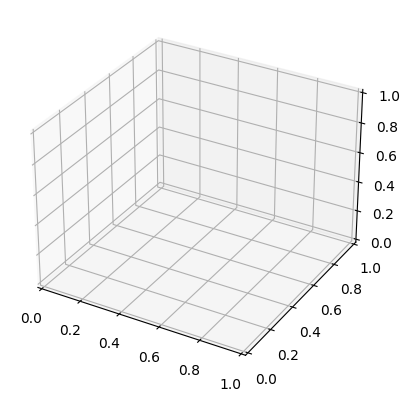

In [20]:
fig = plt.figure()
ax = plt.axes(projection='3d')

aa, bb = np.meshgrid(np.arange(-10, 10, 0.5), np.arange(-50, 50, 0.5))

cost_l = sp.lambdify([aa, bb], cost)
# zz = cost_l(aa, bb)

# ax.plot_surface(aa, bb, zz, alpha=0.3)


In [ ]:
dJda = cost.diff(a)
dJdb = cost.diff(b)

display(sp.Equality(sp.Derivative('cost(a,b)', a), dJda))
print()
display(sp.Equality(sp.Derivative('cost(a,b)', b), dJdb))

In [ ]:
def step(f, a0, b0, lr):
  da = dJda.subs([(a, a0), (b, b0)])
  db = dJdb.subs([(a, a0), (b, b0)])
  print(f'{da=:.1} {db=:.1}')
  return a0 - lr * da, b0 - lr * db

In [ ]:
def train(f, epochs=20, lr=1e-3):
  a0, b0 = 3.0, 1.0
  costs = []
  for i in range(epochs):
    c = cost.subs([(a, a0), (b, b0)])
    costs.append(c)
    print(f'step #{i}:    cost={c}  (a0, b0) = ({a0:.2}, {b0:.2})')
    f0 = f.subs([(a,a0), (b,b0)])
    show_function_and_cloud(f0)
    a0, b0 = step(f, a0, b0, lr)

  plt.plot(costs)
  plt.title('cost')
  plt.show()


In [ ]:
train(f, 3)